이전에 [데이터 기초](./2026-05-22_data_analysis_basic.ipynb) 를 2026-05-22 04시쯤에 했고

현재 2026-05-22 21:30 에 복습 한 뒤 다음 단계 (히스토그램, 시각화 등)으로 넘어가려 한다.

In [1]:
import pandas as pd
import numpy as nd

data = pd.Series([10, 20, 30, 40, 50, 60, 70, 80, 900])



print(f"mean: {data.mean()}")
print(f"median: {data.median()}")
print(f"std: {data.std(ddof=1)}")

q1 = data.quantile(0.25)
q2 = data.quantile(0.5)
q3 = data.quantile(0.75)
print(f"q1: {q1}")
print(f"q2: {q2}")
print(f"q3: {q3}")

iqr = q3-q1
print(f"iqr: {iqr}")
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print(f"lower_bound: {lower_bound}")
print(f"upper_bound: {upper_bound}")

print(f"outliner: {data[(data < lower_bound ) | (data > upper_bound)]}")


ModuleNotFoundError: No module named 'pandas'

평균값이 140인 데이터가 있다. 이는 중앙값이 50이지만 outliner이 900인 값이 하나가 존재하기 때문이다. 이때문에 분산이 약285가 되어있었다.

---

# 분포와 시각화
이것은 이론보다는 숫자로 요약한 데이터 상태를 그림으로 보고 해석하는 감각을 기르는 작업입니다.
이를 통해서 너무 많은 데이터 셋을 한눈에 확인 가능한 데이터 셋으로 만들어서 한눈에 데이터의 상태를 확인 가능하게 됩니다.

In [2]:
try:
    import pandas as pd
except ImportError:
    pass

scores = [45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 95, 100, 150]

s = pd.Series(scores)

# 기본 통계
print(s.describe())

count     20.000000
mean      76.100000
std       23.208211
min       45.000000
25%       61.500000
50%       73.500000
75%       85.750000
max      150.000000
dtype: float64


1. 평균은 얼마인가?
- 76.1
2. 중앙값은 얼마인가?
- 73
3. 평균이 중앙값보다 큰 이유는 무엇인가?
- 중앙값을 기준으로 더 큰 수들의 편차 제곱의 합이 더 커서. (더 멀리 퍼져 있어서)
4. 표준편차가 커진 이유는 무엇인가?
- 중앙값 기준 더 큰 값들이 더 멀리 존재해서
5. 이 데이터에서 의심되는 이상치는 무엇인가?
- q3이 85.75인데 150으로 존재하는 max

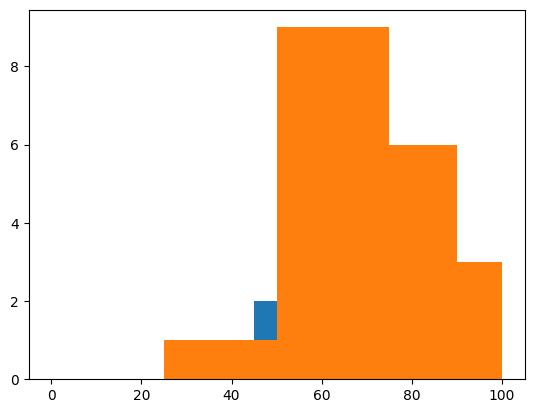

In [ ]:
# 데이터 시각화 라이브러리 matplotlib
# 그중에서 파이썬에서 그래프를 그리는 대표 라이브러리 pyplot
import matplotlib.pyplot as plt

scores = [45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 95, 100, 150]

# (데이터 셋, 
# plt.hist(s, bins=10)
plt.hist(s, bins=[0, 25, 50, 75, 90, 100])
# 45 ~ 110 까지 데이터가 1~4개 존재하며 140 이상에 하나 존재
plt.show()

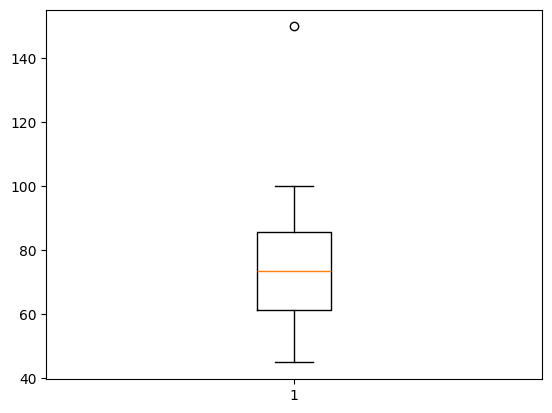

In [6]:
# 박스플롯
# 사분위수, IQR, 이상치를 한번에 보여주는 그래프
plt.boxplot(s)
plt.show()
# 이상치가 하나 존재하는 모습을 확인 가능. 
# 약 q1: 60초반, q2: 70쯤, q3: 85쯤

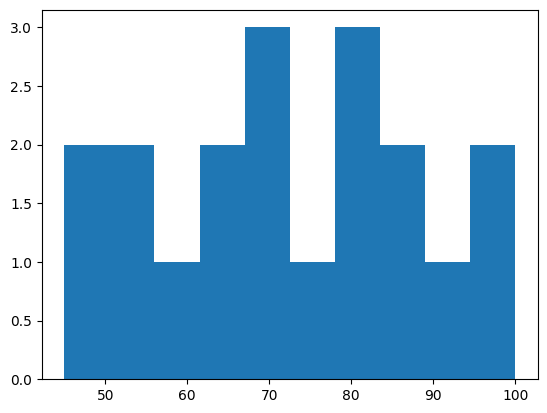

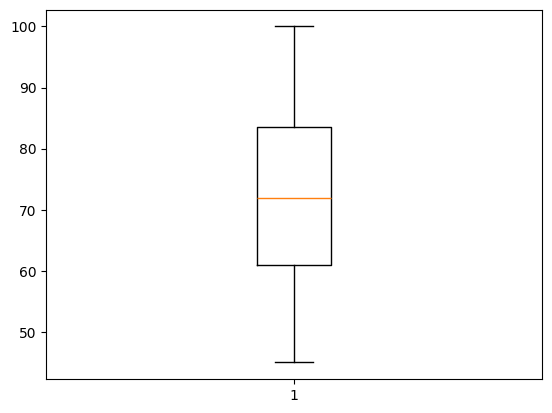

In [ ]:
# 데이터 시각화 라이브러리
try:
    import matplotlib.pyplot as plt
except ImportError:
    pass
    
# 이상치 제거
scores = [45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 95, 100,]

s = pd.Series(scores)

# 히스토그램
plt.hist(s, bins=10)
plt.show()
# 박스플롯
plt.boxplot(s)
plt.show()

# 좀 더 골고루 나누어지는 모습

# 시각화 방법들의 종류
## 1. 히스토그램
히스토그램은 막대 그래프 처럼 보이지만 엄밀히 말하면 **연속형 데이터의 분포**를 나타내는 그래프입니다.
데이터의 수치와 간격에 따라서 데이터의 개수를 보여주는 방식으로 데이터가 어떻게 분포되었으며 `문서 길이 분포`, `토큰 수 분포`, `처리 시간 분포`, `신뢰도 점수 분포` 등을 볼 때 적절히 안정적으로 분포가 되어있는지, 이상치가 있는지 등을 확인할 때 보기 좋습니다.

## 2. 박스플롯
너무 긴 문서, 너무 오래 걸리는 요청, 데이터들에 숨어있는 이상치의 개수 등이 있는지 체크하기 위해 사용합니다.
중간 박스 속에 있는 데이터가 많으며 양 끝 수평선 사이에 있는 데이터가 아닌 것들을 이상치 후보로 선택하게 됩니다.

## 3. 산점도
산점도는 x축과 y축의 변수를 통해서 두 변수 사이의 전체적인 관계를 파악할 때 사용될 수 있습니다.

## 4. 선 그래프
산점도와 비슷하게 x축과 y축을 바탕으로 상관관계를 보기 위해 사용하지만 시간의 흐름에 따른 변화를 확인하기 위해 사용하는 경우가 많습니다.
그 밖에도 온도, 압력, 거리 등과 같은 x축에 **순서와 연속성**이 있는 데이터일 경우에 많이 쓰이게 됩니다.

## 5. 막대그래프
특정 카테고리당 개수, 평균 등과 같은 수치를 보기 위해 사용됩니다.
히스토그램과 다르게 연속적인 데이터가 아니여도 쓰이게 됩니다.

## 6. 히트맵
위치에 따른 x와 y에 따라 데이터를 분포시키며 더 많이 밀집될수록 밝기/진하기를 강하게 만듭니다.
산점도와 다르게 데이터의 밀도, 패턴, 강도를 시각화 합니다. 대규모 데이터 패턴 파악에 용이합니다.


In [12]:
try:
  import pandas as pd
except ImportError:
  pass

try:
  import matplotlib.pyplot as plt
except ImportError:
  pass

df = pd.DataFrame({
    "frame": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "object_count": [2, 3, 3, 4, 5, 4, 20, 3, 2, 5],
    "inference_time": [45, 50, 48, 55, 60, 58, 180, 52, 47, 62],
    "object_type": ["person", "car", "person", "dog", "car", "person", "car", "dog", "person", "car"]
})

# 영상 프레임별 탐지된 객체와 그 수, 추론 처리 시간
print(df)
print(df[["inference_time", "object_count"]].describe())

   frame  object_count  inference_time object_type
0      1             2              45      person
1      2             3              50         car
2      3             3              48      person
3      4             4              55         dog
4      5             5              60         car
5      6             4              58      person
6      7            20             180         car
7      8             3              52         dog
8      9             2              47      person
9     10             5              62         car
       inference_time  object_count
count       10.000000       10.0000
mean        65.700000        5.1000
std         40.565585        5.3427
min         45.000000        2.0000
25%         48.500000        3.0000
50%         53.500000        3.5000
75%         59.500000        4.7500
max        180.000000       20.0000


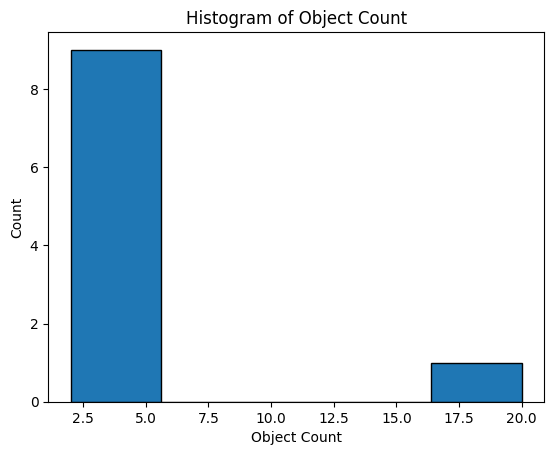

In [13]:
import matplotlib.pyplot as plt
# 히스토그램 작성. 탐지된 개수들이 어떤식으로 분포되어있는지 확인하는 용도
# df["object_count"]: Series 라서 가능
plt.hist(df["object_count"], bins=5, edgecolor="black")
plt.xlabel("Object Count")
plt.ylabel("Count")
plt.title("Histogram of Object Count")
plt.show()

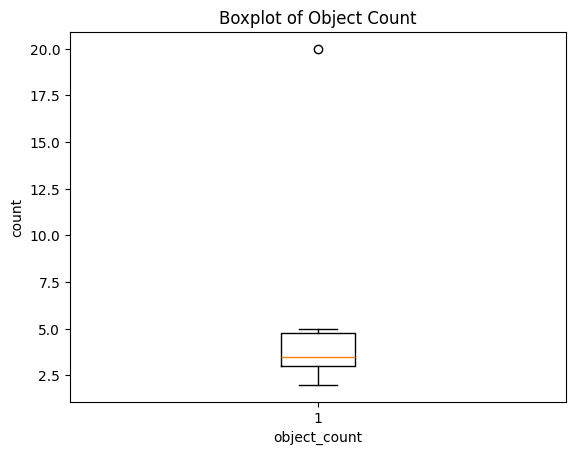

In [15]:
plt.boxplot(df["object_count"])
plt.xlabel("object_count")
plt.ylabel("count")
plt.title("Boxplot of Object Count")
plt.show() # 이상치 하나 라기 보다는 한 프레임에서 많은 객체 탐지됨

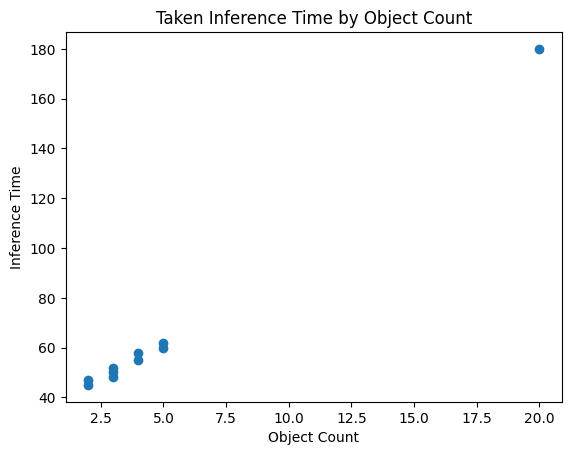

In [ ]:
# 산점도: 첫번째 인자: x, 두번째 인자: y
plt.scatter(df["object_count"], df["inference_time"])
plt.xlabel("Object Count")
plt.ylabel("Inference Time")
plt.title("Taken Inference Time by Object Count")
plt.show() # 정비례 관계로 보이는 산점도 모습 

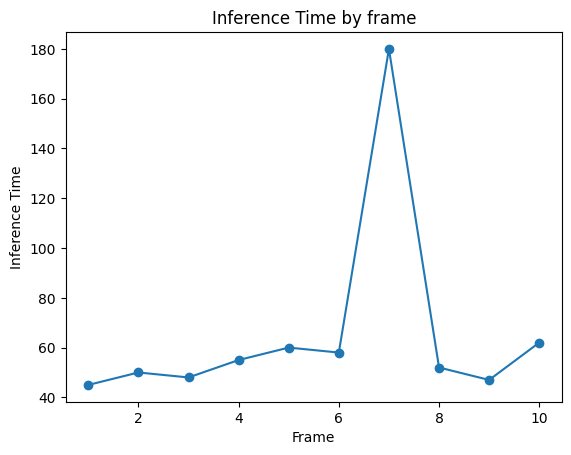

In [19]:
# 선 그래프. 점들을 모두 이은 모습. 
# 프레임 흐름에 따른 분석 시간(객체 개수)
plt.plot(df["frame"], df["inference_time"], marker="o")
plt.xlabel("Frame")
plt.ylabel("Inference Time")
plt.title("Inference Time by frame")
plt.show()

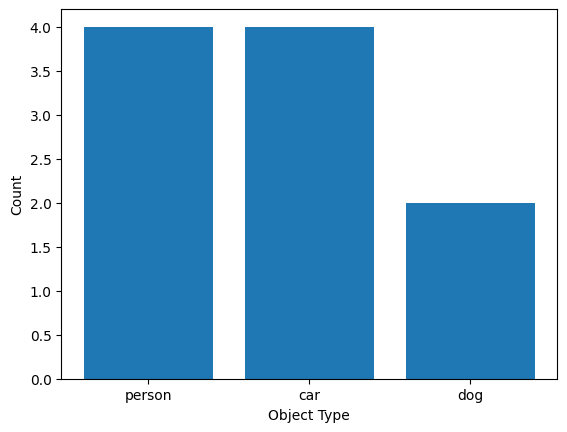

In [29]:
# # 막대그래프
# # 범주별 개수 비교

# # 잘못된 코드
# # counts = df.groupby("object_type").count()

# # 객체 종류들 Series 뽑은 다음, 거기에서 value별 개수 뽑기
counts = df["object_type"].value_counts() # Series
# counts.values.dtype # int64
plt.bar(counts.index, counts.astype(int).tolist())
plt.xlabel("Object Type")
plt.ylabel("Count")
plt.show() # 모두 4정도, 개만 2

# 정규분포와 z-score
정규분포는 평균 주변에 값이 많이 몰리고, 양쪽으로 갈수록 적어지는 종 모양의 분포입니다.

z-score은 어떤 값이 평균에서 표준편차 몇개만큼 떨어져있는지 나타내는 값 입니다.

## 정규분포
정규분포는 대략적으로 아래와 같은 모습을 가집니다.
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/8/8c/Standard_deviation_diagram.svg/1280px-Standard_deviation_diagram.svg.png?utm_source=ko.wikipedia.org&utm_campaign=index&utm_content=thumbnail" style="width: 400px; background-color: white">

이때, 사진에 보이는 범위가 바로 시그마라는 개념으로 `68-95-99.7` 규칙이라는 것입니다.

- 평균 ± 1 표준편차 안이 약 68%
- 평균 ± 2표준편차 안에 약 95%
- 평균 ± 3표준편차 안에 약 99.7%

이라는 의미입니다.

에를 들어 평균이 `70`, 표준편차가 `10`이라면 
- 1시그마: 60~80 (68%)
- 2시그마: 50~90 (95%)
- 3시그마: 40~100 (99.7%)

이렇게 점점 바깥쪽에 상태가 위치할 수록 이상치 후보에 가깝다고 생각할 수 있습니다.

## z-score
z-score은 다음과 같습니다.
```
z = (값 - 평균) / 표준편차
```
이는 계산하려는 값이 데이터셋의 평균에 비해 표준편차 몇개만큼 차이가 나는지 확인하는 작업입니다.

예를 들어
- 평균: `70`
- 표준편차: `10`
- 분석할 값: `90`

이라고 한다면 값, `90`의 `z-score`은 `(90 - 70)/10 = 2` 가 되며 2시그마에 위치한다고 볼 수 있습니다.

일반적으로 ±3시그마 밖의 데이터를 이상치 후보로 설정하게 됩니다.

In [40]:
try:
  import pandas as pd
except ImportError:
  pass

scores = [45, 50, 52, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 95, 100, 150]

s = pd.Series(scores)

mean = s.mean()
# 델타 자유도 (데이터 개수에서 뺴는 값) - 모분산: 0
std = s.std(ddof=0)

z_scores = (s-mean)/std

# print(z_scores)
# count per each sigma
z_scores_sigma_group = pd.cut(z_scores.abs(), bins=[0, 1, 2, 3, float("inf")], 
             labels=["1sigma", "2sigma", "3sigma", "outliner"],
             include_lowest=True)
print(z_scores_sigma_group.value_counts())
# outliner value
print(f"\n --- outliner ---")
print(s[z_scores_sigma_group=="outliner"])
print(z_scores[z_scores_sigma_group=="outliner"])

1sigma      15
2sigma       4
outliner     1
3sigma       0
Name: count, dtype: int64

 --- outliner ---
19    150
dtype: int64
19    3.266939
dtype: float64


In [44]:
df = pd.DataFrame({
  "score": scores
})

df["z_score"] = (df["score"] - df["score"].mean()) / df["score"].std(ddof=0)
df["sigma"] = z_scores_sigma_group

print(df.sort_values("sigma"))

    score   z_score     sigma
9      72 -0.181251    1sigma
17     95  0.835523    1sigma
16     90  0.614485    1sigma
3      55 -0.932779    1sigma
4      60 -0.711742    1sigma
5      62 -0.623327    1sigma
6      65 -0.490704    1sigma
7      68 -0.358081    1sigma
8      70 -0.269666    1sigma
15     88  0.526070    1sigma
10     75 -0.048628    1sigma
11     78  0.083994    1sigma
12     80  0.172409    1sigma
13     82  0.260825    1sigma
14     85  0.393447    1sigma
0      45 -1.374855    2sigma
2      52 -1.065402    2sigma
1      50 -1.153817    2sigma
18    100  1.056561    2sigma
19    150  3.266939  outliner


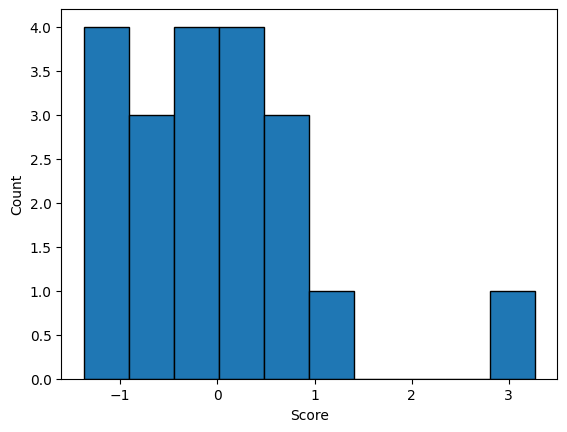

In [47]:
plt.hist(df["z_score"], bins=10, edgecolor="black")
plt.xlabel("Score")
plt.ylabel("Count")
plt.show()